In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [6]:
df = pd.read_csv("Churn_Modelling.csv")

In [7]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [8]:
info = pd.DataFrame({
    "dtype"    : df.dtypes,
    "nulls"    : df.isnull().sum(),
    "unique"   : df.nunique()
})

In [9]:
print(df.describe().T)

                   count          mean           std          min  \
RowNumber        10000.0  5.000500e+03   2886.895680         1.00   
CustomerId       10000.0  1.569094e+07  71936.186123  15565701.00   
CreditScore      10000.0  6.505288e+02     96.653299       350.00   
Age              10000.0  3.892180e+01     10.487806        18.00   
Tenure           10000.0  5.012800e+00      2.892174         0.00   
Balance          10000.0  7.648589e+04  62397.405202         0.00   
NumOfProducts    10000.0  1.530200e+00      0.581654         1.00   
HasCrCard        10000.0  7.055000e-01      0.455840         0.00   
IsActiveMember   10000.0  5.151000e-01      0.499797         0.00   
EstimatedSalary  10000.0  1.000902e+05  57510.492818        11.58   
Exited           10000.0  2.037000e-01      0.402769         0.00   

                         25%           50%           75%          max  
RowNumber            2500.75  5.000500e+03  7.500250e+03     10000.00  
CustomerId       15628528.2

In [11]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


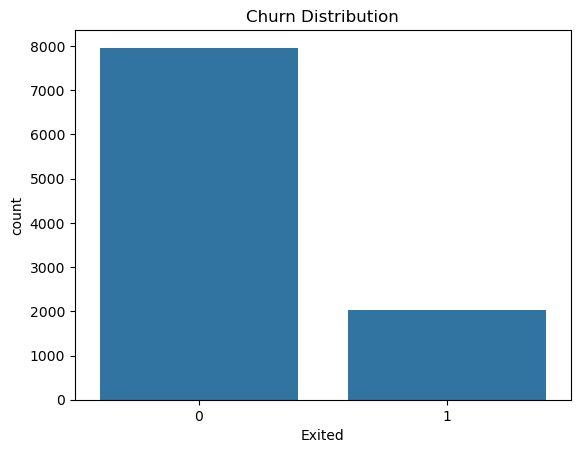

In [10]:
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

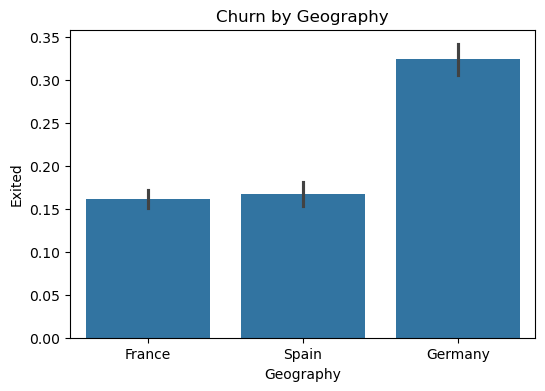

In [12]:
# Geography vs Churn
plt.figure(figsize=(6,4))
sns.barplot(x="Geography", y="Exited", data=df)
plt.title("Churn by Geography")
plt.show()

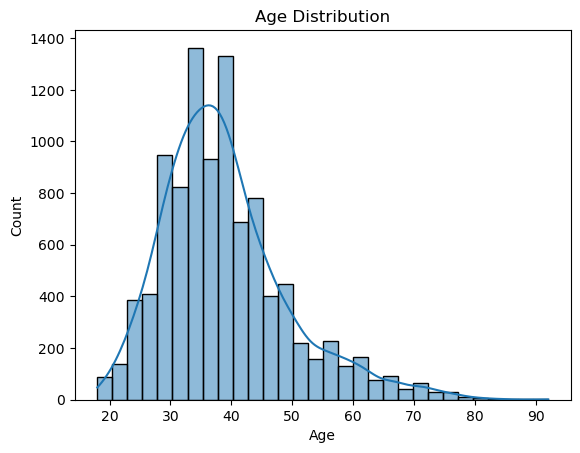

In [13]:
# Age distribution
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

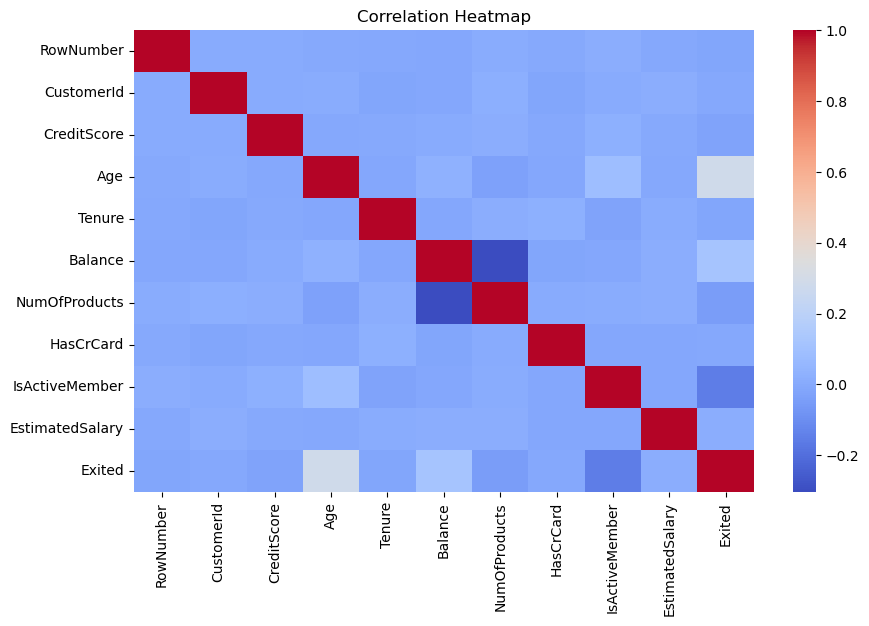

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df_model = df.copy()

# Encode categorical columns
le_geo = LabelEncoder()
df_model["Geography"] = le_geo.fit_transform(df_model["Geography"])
df_model["Gender"] = df_model["Gender"].map({"Male": 0, "Female": 1})

In [16]:
X = df_model.drop(["Exited", "RowNumber", "CustomerId", "Surname"], axis=1)
y = df_model["Exited"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}


   

In [24]:

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve)
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, prob)

    results[name] = [acc, auc]

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC-AUC:", auc)




Logistic Regression
Accuracy: 0.805
ROC-AUC: 0.771043771043771

Decision Tree
Accuracy: 0.782
ROC-AUC: 0.6701647718596871

Random Forest
Accuracy: 0.866
ROC-AUC: 0.8460694901372867

Gradient Boosting
Accuracy: 0.8675
ROC-AUC: 0.8672131299249943


[[1541   52]
 [ 213  194]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



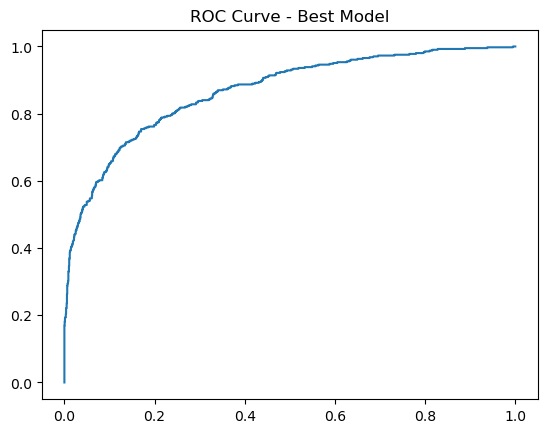

In [22]:
best_model = GradientBoostingClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC Curve - Best Model")
plt.show()

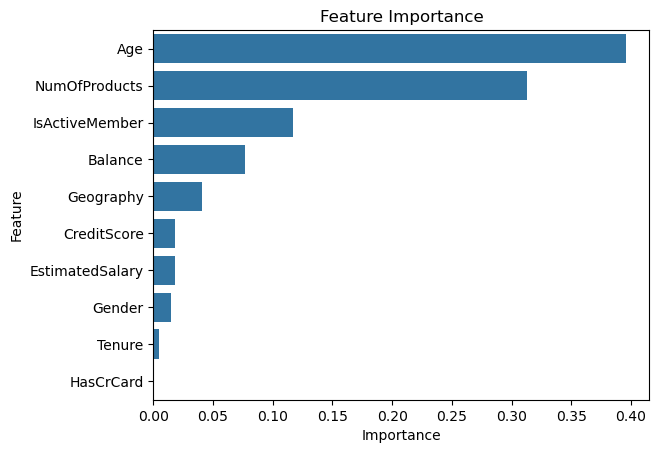

In [25]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [29]:
import urllib.parse
import pandas as pd
from sqlalchemy import create_engine

# 1. PostgreSQL Connection Details
username = "postgres"
password = "abhi2005"
host = "localhost"
port = "5432"
database = "bank_churn_db"
encoded_database = urllib.parse.quote(database)

# Create the SQLAlchemy Engine
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{encoded_database}"
)
df.to_sql(
    "customer_churn",
    engine,
    if_exists="replace",
    index=False,
    chunksize=50000, 
    method="multi"    
)

print("Data loaded successfully into table 'bank chur'!")

Data loaded successfully into table 'bank chur'!
